# Data Science and AI Bootcamp - 2026
## Module 5 - Fundamentals of Contemporary AI (Practical)

Welcome! In this session we will solve the **exact same problem** — classifying handwritten digits (the classic MNIST dataset) — using three different approaches:

1. **A classical machine learning model** (Logistic Regression) — no deep learning at all
2. **A deep learning model** (a Multi-Layer Perceptron, trained with PyTorch)
3. **A zero-shot Vision-Language Model (VLM)** — a general-purpose model that was never trained on a single digit, yet can still attempt the task. You'll pick which VLM to demo live: **CLIP** or **BLIP-VQA**.

At the end, we'll put all three side by side and discuss when you'd actually want to use each one in the real world. As a bonus, we'll also generate spoken audio using an open-source text-to-speech model.

### Before you start

Select a GPU runtime before running the notebook.

- **Google Colab (Free tier):** Go to Runtime → Change runtime type → Hardware accelerator → GPU (T4), then click `Save`.
- **Google Colab Enterprise:** Go to Connect → Connect to a runtime → Connect to an existing Runtime → Select a GPU template, select an available GPU (for example, L4 if available), then click `Connect`.

This notebook is designed to run on Google Colab's free tier using a T4 GPU. On Colab Enterprise, any supported NVIDIA GPU should work, although performance may vary.

### Agenda (≈60 minutes)
| Section | Time |
|---|---|
| 0. Setup & Orientation | 5 min |
| 1. Exercise 1 — Classical ML Baseline | 10 min |
| 2. Exercise 2 — MLP with PyTorch | 18 min |
| 3. Exercise 3 — Zero-Shot Classification with a VLM (choose CLIP or BLIP-VQA) | 15 min |
| 4. Head-to-Head Comparison | 7 min |
| 5. Bonus — Text-to-Speech | optional |

Just run each cell in order — every section explains what it's doing and why before you get to the code.

---
# 0. Setup & Orientation

In this section we will:
- Install and import the libraries we need
- Confirm we have a GPU available
- Download the MNIST dataset
- Build one small, shared subset of MNIST that **all three exercises will use**
- Look at a few sample images


In [1]:
# Install/upgrade the libraries used in this session.
# Most of these already ship with Google Colab, but we upgrade them here
# so that everyone in the room is working with the same versions.
# ipywidgets powers the VLM picker in Exercise 3.
!pip install -q --upgrade transformers scikit-learn ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.3 MB/s eta 0:00:00


In [31]:
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Fix random seeds so that results are reproducible across runs and machines.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


## Checking for a GPU

Deep learning involves a huge number of repeated matrix multiplications. GPUs (Graphics Processing Units) are built to do exactly that kind of math in parallel, which makes them dramatically faster than a regular CPU for training and running neural networks. The cell below confirms Colab has handed us one.


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Go to Runtime -> Change runtime type -> GPU (T4), then re-run this cell.")

Using device: cpu
No GPU detected. Go to Runtime -> Change runtime type -> GPU (T4), then re-run this cell.


## About the dataset: MNIST

[MNIST](https://en.wikipedia.org/wiki/MNIST_database) is a dataset of 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels. It has been a standard "hello world" benchmark for image classification for decades — small enough to train on quickly, but non-trivial enough to be a genuine test of a model's ability to recognize visual patterns.


In [33]:
print("Downloading MNIST (this happens once and is cached locally)...")
mnist_train_full = datasets.MNIST(root="./data", train=True, download=True)
mnist_test_full = datasets.MNIST(root="./data", train=False, download=True)

print(f"Full training set size: {len(mnist_train_full)} images")
print(f"Full test set size:     {len(mnist_test_full)} images")

Full training set size: 60000 images
Full test set size:     10000 images


## Building one shared subset for all three exercises

The full MNIST dataset has 70,000 images. To keep every exercise fast enough to run live, we'll work with a much smaller **class-balanced** slice: 600 training images and 100 test images *per digit* — 6,000 training images and 1,000 test images in total.

Importantly, **all three exercises use the same data slice**, ensuring that the final accuracy comparison is based on identical input data.

In [34]:
def balanced_subset_indices(dataset, n_per_class, seed=SEED):
    """Return a list of dataset indices containing exactly n_per_class examples of each digit."""
    rng = np.random.default_rng(seed)
    targets = dataset.targets.numpy()
    indices = []
    for digit in range(10):
        digit_indices = np.where(targets == digit)[0]
        chosen = rng.choice(digit_indices, size=n_per_class, replace=False)
        indices.extend(chosen.tolist())
    rng.shuffle(indices)
    return indices

TRAIN_PER_CLASS = 600   # -> 6,000 training images total
TEST_PER_CLASS = 100    # -> 1,000 test images total

train_indices = balanced_subset_indices(mnist_train_full, TRAIN_PER_CLASS)
test_indices = balanced_subset_indices(mnist_test_full, TEST_PER_CLASS)

print(f"Shared training subset: {len(train_indices)} images (balanced across all 10 digits)")
print(f"Shared test subset:     {len(test_indices)} images (balanced across all 10 digits)")

Shared training subset: 6000 images (balanced across all 10 digits)
Shared test subset:     1000 images (balanced across all 10 digits)


In [35]:
def dataset_subset_to_numpy(dataset, indices):
    """Pull a subset of a torchvision MNIST dataset into plain numpy arrays."""
    images = dataset.data[indices].numpy()      # shape: (N, 28, 28), pixel values 0-255
    labels = dataset.targets[indices].numpy()   # shape: (N,)
    return images, labels

train_images, train_labels = dataset_subset_to_numpy(mnist_train_full, train_indices)
test_images, test_labels = dataset_subset_to_numpy(mnist_test_full, test_indices)

print(f"train_images shape: {train_images.shape}, train_labels shape: {train_labels.shape}")
print(f"test_images shape:  {test_images.shape},  test_labels shape:  {test_labels.shape}")

train_images shape: (6000, 28, 28), train_labels shape: (6000,)
test_images shape:  (1000, 28, 28),  test_labels shape:  (1000,)


Let's look at a few of the images we'll be working with:

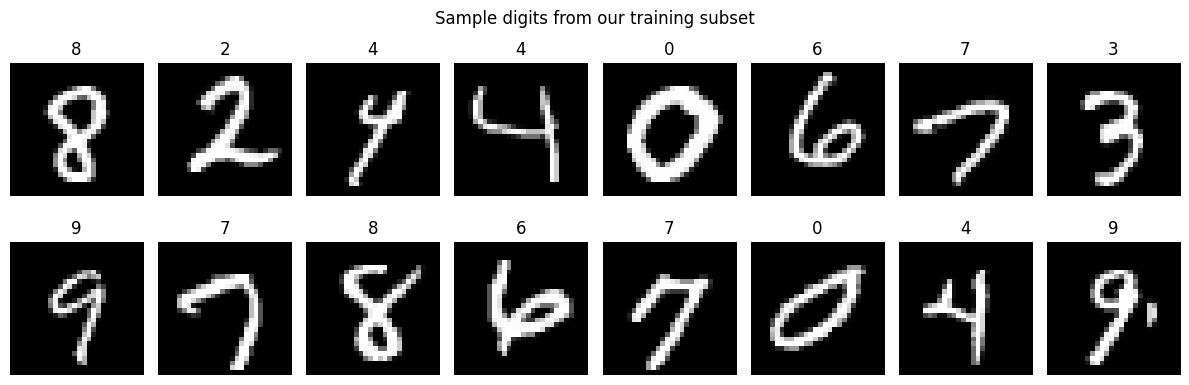

In [36]:
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(str(train_labels[i]))
    ax.axis("off")
plt.suptitle("Sample digits from our training subset")
plt.tight_layout(h_pad=3.0)
plt.show()

## A helper we'll reuse across all three exercises

We'll evaluate every method the same way, so let's write one confusion-matrix plotting function now and reuse it three times. A confusion matrix shows, for every true digit (rows), what the model actually predicted (columns) — the diagonal is correct predictions, everything off the diagonal is a mistake.

We'll also keep a `results` dictionary that collects each method's accuracy, timing, and size, ready for the comparison in Section 4.


In [37]:
def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a 10x10 confusion matrix for digit predictions (0-9)."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xlabel("Predicted digit")
    ax.set_ylabel("True digit")
    ax.set_title(title)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# We'll add one entry to this dictionary after each exercise.
results = {}

---
# 1. Exercise 1 — Classical Machine Learning Baseline

Before reaching for deep learning, it's worth asking: how far can a *simple* model get?

**[Logistic Regression](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/)** is a classical, linear machine learning model. For our task, it treats each of the 784 pixels in an image as an independent input feature, and learns one weight per pixel per digit class — essentially asking "which pixels, when bright, make this look like a 3? or a 7?" It has no concept of shape, edges, or the fact that neighboring pixels are related — it just learns a weighted sum of raw pixel brightness.

This makes it fast to train and easy to interpret, but limited in how well it can understand visual patterns. It's a great baseline: if a much more complex model can't beat this, that complexity isn't earning its keep.


![LR](https://raw.githubusercontent.com/rochanaro/contemporary-ai-2026/refs/heads/main/figures/logistic_regression.png)

### Step 1: Prepare the data

Logistic Regression expects a flat vector of numbers per example, not a 2D image. We'll "flatten" each 28×28 image into a single vector of 784 pixel values, and scale pixel values from the 0–255 range down to 0–1 (models generally train better on small, consistent number ranges).


In [38]:
X_train_flat = train_images.reshape(len(train_images), -1).astype(np.float32) / 255.0
X_test_flat = test_images.reshape(len(test_images), -1).astype(np.float32) / 255.0

print(f"X_train_flat shape: {X_train_flat.shape}   (6,000 images x 784 pixels each)")
print(f"X_test_flat shape:  {X_test_flat.shape}    (1,000 images x 784 pixels each)")

X_train_flat shape: (6000, 784)   (6,000 images x 784 pixels each)
X_test_flat shape:  (1000, 784)    (1,000 images x 784 pixels each)


### Step 2: Train the model

In [39]:
log_reg = LogisticRegression(max_iter=2000)

start_time = time.time()
log_reg.fit(X_train_flat, train_labels)
train_time_lr = time.time() - start_time

print(f"Logistic Regression trained in {train_time_lr:.2f} seconds.")

Logistic Regression trained in 7.73 seconds.


### Step 3: Evaluate the model

Test accuracy: 88.70%
Inference time for 1000 images: 0.007 seconds
Number of learned parameters: 7,850


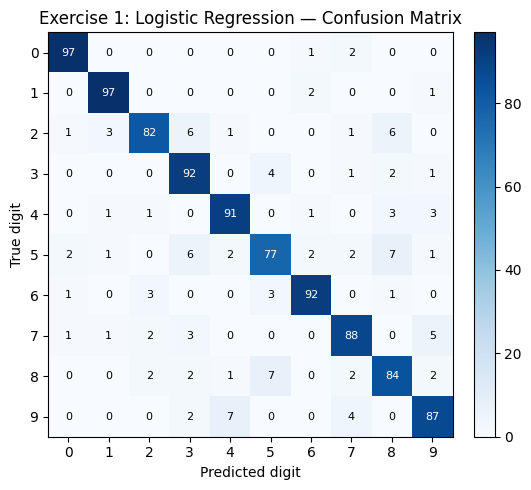

In [40]:
start_time = time.time()
lr_predictions = log_reg.predict(X_test_flat)
inference_time_lr = time.time() - start_time

accuracy_lr = accuracy_score(test_labels, lr_predictions)
n_params_lr = log_reg.coef_.size + log_reg.intercept_.size

print(f"Test accuracy: {accuracy_lr * 100:.2f}%")
print(f"Inference time for {len(test_labels)} images: {inference_time_lr:.3f} seconds")
print(f"Number of learned parameters: {n_params_lr:,}")

plot_confusion_matrix(test_labels, lr_predictions, "Exercise 1: Logistic Regression — Confusion Matrix")

results["Logistic Regression"] = {
    "Training required": "Yes",
    "Training time (s)": round(train_time_lr, 2),
    "Inference time (s)": round(inference_time_lr, 3),
    "Test accuracy": round(accuracy_lr, 4),
    "Parameters": n_params_lr,
}

**Take a look at the confusion matrix above.** Which digit pairs get confused most often? It's usually digits that look visually similar when handwritten quickly — for example 4/9, 3/5, or 7/9. This is exactly the kind of subtle visual/shape reasoning a purely pixel-weighted linear model struggles with.


---
# 2. Exercise 2 — Multi-Layer Perceptron (MLP) with PyTorch

A **[Multi-Layer Perceptron](https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/)** is the simplest kind of deep neural network: a stack of layers, where each layer applies a linear transformation followed by a non-linear "activation function." That non-linearity is the key difference from Logistic Regression (which is essentially a single linear layer) — stacking non-linear layers lets the network learn much more complex, curved decision boundaries instead of a single straight-line-style separation between classes.

We'll build a network with the shape:

`784 pixels → 256 neurons → 128 neurons → 10 digit scores`

and **train** it — meaning we'll show it the training images repeatedly, measure how wrong its predictions are, and nudge its weights to be a little less wrong each time, using an algorithm called gradient descent.


![MLP](https://raw.githubusercontent.com/rochanaro/contemporary-ai-2026/refs/heads/main/figures/mlp.png)

### Step 1: Build PyTorch datasets and data loaders

PyTorch works with its own `Dataset` and `DataLoader` objects, which handle batching (grouping several images together) and shuffling automatically. `transforms.ToTensor()` converts each image from a 0–255 pixel-value image into a PyTorch tensor scaled to 0–1, in the shape PyTorch expects: `(channels, height, width)`.


In [41]:
transform = transforms.ToTensor()

mnist_train_full_t = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test_full_t = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Reuse the exact same indices as Exercise 1, so the training/test data matches exactly.
train_subset = Subset(mnist_train_full_t, train_indices)
test_subset = Subset(mnist_test_full_t, test_indices)

BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)} (batch size {BATCH_SIZE})")
print(f"Number of test batches:     {len(test_loader)}")

Number of training batches: 94 (batch size 64)
Number of test batches:     16


### Step 2: Define the model

- `nn.Flatten()` turns each 28×28 image into a 784-length vector (same idea as Exercise 1)
- `nn.Linear(in, out)` is a fully-connected layer: every input is connected to every output with a learnable weight
- `nn.ReLU()` is the activation function: it simply zeroes out negative values (`ReLU(x) = max(0, x)`). This small non-linearity, repeated across layers, is what gives neural networks their expressive power
- The final layer outputs 10 numbers (one "score" per digit); the highest score is the model's prediction


In [42]:
class MLP(nn.Module):
    """A simple fully-connected neural network for digit classification."""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),              # (batch, 1, 28, 28) -> (batch, 784)
            nn.Linear(28 * 28, 256),   # first hidden layer
            nn.ReLU(),
            nn.Linear(256, 128),       # second hidden layer
            nn.ReLU(),
            nn.Linear(128, 10),        # output layer: one score per digit (0-9)
        )

    def forward(self, x):
        return self.layers(x)

mlp_model = MLP().to(device)
print(mlp_model)

n_params_mlp = sum(p.numel() for p in mlp_model.parameters())
print(f"\nTotal trainable parameters: {n_params_mlp:,}")

MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 235,146


### Step 3: Define the loss function and optimizer

- **Loss function** (`CrossEntropyLoss`): measures how wrong the model's predictions are compared to the true labels. Lower is better.
- **Optimizer** (`Adam`): the algorithm that uses the loss to decide how to adjust every weight in the network, a little bit, after each batch.


In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

### Step 4: Train the model

One pass through the *entire* training set is called an **epoch**. For each batch of images in each epoch, the training loop does four things:
1. **Forward pass** — run the images through the network to get predictions
2. **Compute loss** — compare predictions to the true labels
3. **Backward pass** — compute how much each weight contributed to the error (`loss.backward()`)
4. **Update weights** — nudge every weight slightly to reduce the error (`optimizer.step()`)


In [44]:
NUM_EPOCHS = 15
train_losses = []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    mlp_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # reset gradients from the previous step
        outputs = mlp_model(images)    # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backward pass: compute gradients
        optimizer.step()               # update the model's weights

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_subset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} - training loss: {epoch_loss:.4f}")

train_time_mlp = time.time() - start_time
print(f"\nTotal training time: {train_time_mlp:.2f} seconds")

Epoch  1/15 - training loss: 0.8912
Epoch  2/15 - training loss: 0.3447
Epoch  3/15 - training loss: 0.2641
Epoch  4/15 - training loss: 0.2054
Epoch  5/15 - training loss: 0.1679
Epoch  6/15 - training loss: 0.1327
Epoch  7/15 - training loss: 0.1022
Epoch  8/15 - training loss: 0.0768
Epoch  9/15 - training loss: 0.0615
Epoch 10/15 - training loss: 0.0413
Epoch 11/15 - training loss: 0.0363
Epoch 12/15 - training loss: 0.0274
Epoch 13/15 - training loss: 0.0205
Epoch 14/15 - training loss: 0.0120
Epoch 15/15 - training loss: 0.0112

Total training time: 13.30 seconds


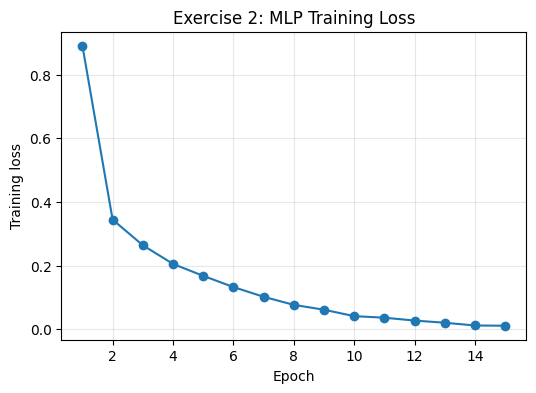

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Exercise 2: MLP Training Loss")
plt.grid(alpha=0.3)
plt.show()

A steadily decreasing loss curve means the model is successfully learning from the training data. If you ever see the loss stop decreasing or start increasing, that's usually a sign the learning rate is too high, or the model needs more/less capacity.

### Step 5: Evaluate the model


Test accuracy: 94.40%
Inference time for 1000 images: 0.123 seconds


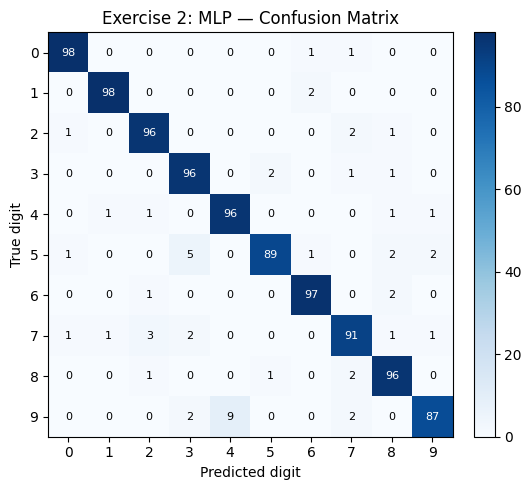

In [46]:
mlp_model.eval()
all_preds = []
all_labels = []

start_time = time.time()
with torch.no_grad():  # we don't need gradients for evaluation, this saves memory and time
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
inference_time_mlp = time.time() - start_time

accuracy_mlp = accuracy_score(all_labels, all_preds)
print(f"Test accuracy: {accuracy_mlp * 100:.2f}%")
print(f"Inference time for {len(all_labels)} images: {inference_time_mlp:.3f} seconds")

plot_confusion_matrix(all_labels, all_preds, "Exercise 2: MLP — Confusion Matrix")

results["MLP (PyTorch)"] = {
    "Training required": "Yes",
    "Training time (s)": round(train_time_mlp, 2),
    "Inference time (s)": round(inference_time_mlp, 3),
    "Test accuracy": round(accuracy_mlp, 4),
    "Parameters": n_params_mlp,
}

**Compare this confusion matrix to Exercise 1's.** Did accuracy improve? By how much? Keep in mind this came at a cost too — more parameters, and an actual training loop instead of a single `.fit()` call. We'll weigh that trade-off properly in Section 4.


---
# 3. Exercise 3 — Zero-Shot Classification with a Vision-Language Model

So far, both of our models were trained specifically on MNIST digits. Now we'll try something fundamentally different: a **Vision-Language Model (VLM)** that was never trained on a single digit, yet can still attempt the task using only the general-purpose knowledge it picked up during pretraining.

This notebook supports two VLMs, each representing a different approach to zero-shot classification. **Select one** in the next cell. The remainder of the notebook will automatically use your selected model.

| | **CLIP** | **BLIP-VQA** |
|---|---|---|
| Full name | Contrastive Language-Image Pre-training | Bootstrapping Language-Image Pre-training (VQA variant) |
| Built by | OpenAI | Salesforce |
| How it classifies | Embeds the image and 10 candidate captions, then picks whichever caption's embedding is closest | Directly answers a plain-English question about the image, in generated text |
| Approach | Contrastive, embedding-based | Generative, question-answering |
| Model used | `openai/clip-vit-base-patch32` (~150M params) | `Salesforce/blip-vqa-base` (~385M params) |

Both are freely available on Hugging Face, need no login or API key.

![VLM](https://raw.githubusercontent.com/rochanaro/contemporary-ai-2026/refs/heads/main/figures/vlm.png)

In [47]:
import ipywidgets as widgets
from IPython.display import display

vlm_dropdown = widgets.Dropdown(
    options=[
        ("CLIP  \u2014  openai/clip-vit-base-patch32", "CLIP"),
        ("BLIP-VQA  \u2014  Salesforce/blip-vqa-base", "BLIP-VQA"),
    ],
    value="CLIP",
    description="Choose a VLM:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)
display(vlm_dropdown)
print("\U0001F446 Pick a model above, then run the next cell to lock in your choice.")

Dropdown(description='Choose a VLM:', layout=Layout(width='420px'), options=(('CLIP  —  openai/clip-vit-base-p…

👆 Pick a model above, then run the next cell to lock in your choice.


In [48]:
VLM_CHOICE = vlm_dropdown.value
assert VLM_CHOICE in ("CLIP", "BLIP-VQA")
print(f"Selected VLM for this run: {VLM_CHOICE}")
print("(To switch models later, pick a different option above, then re-run every cell in Section 3 onward.)")

Selected VLM for this run: CLIP
(To switch models later, pick a different option above, then re-run every cell in Section 3 onward.)


### Step 1: Load the selected VLM from Hugging Face

- **CLIP** (`openai/clip-vit-base-patch32`, ~150M parameters) — a relatively small CLIP variant.
- **BLIP-VQA** (`Salesforce/blip-vqa-base`, ~385M parameters) — a compact model purpose-built for visual question answering, and a first-class `transformers` architecture.


In [55]:
from transformers import CLIPModel, CLIPProcessor, BlipProcessor, BlipForQuestionAnswering

if VLM_CHOICE == "CLIP":
    CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
    print("Loading CLIP... (first run downloads the model, then it's cached)")
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
    clip_model.eval()
    n_params_vlm = sum(p.numel() for p in clip_model.parameters())
    print(f"CLIP loaded. Total parameters: {n_params_vlm:,}")

elif VLM_CHOICE == "BLIP-VQA":
    BLIP_MODEL_NAME = "Salesforce/blip-vqa-base"
    print("Loading BLIP-VQA-base... (first run downloads the model, then it's cached)")
    blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
    blip_model = BlipForQuestionAnswering.from_pretrained(BLIP_MODEL_NAME).to(device)
    blip_model.eval()
    n_params_vlm = sum(p.numel() for p in blip_model.parameters())
    print(f"BLIP-VQA-base loaded. Total parameters: {n_params_vlm:,}")

In [58]:
# # If Hugging Face download takes too long,
# # download the pre-packaged model from Google Drive.

# import os
# import tarfile
# from transformers import CLIPModel, CLIPProcessor

# if VLM_CHOICE == "CLIP":
#     CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

#     # Google Drive file ID
#     DRIVE_FILE_ID = "11oJUdcoMiIR_gGwWm4ejdOiBrdYDQeeX"

#     TAR_PATH = "clip_model.tar.gz"
#     EXTRACT_DIR = "./"

#     # After extraction, the model will be in /content/clip_model
#     MODEL_DIR = os.path.join(EXTRACT_DIR, "clip_model")

#     if not os.path.exists(MODEL_DIR):
#         print("Downloading CLIP model from Google Drive...")

#         # gdown is pre-installed on most Colab runtimes
#         os.system(f"gdown --id {DRIVE_FILE_ID} -O {TAR_PATH}")

#         print("Extracting model...")
#         with tarfile.open(TAR_PATH, "r:gz") as tar:
#             tar.extractall(EXTRACT_DIR)

#     print("Loading CLIP model...")
#     clip_model = CLIPModel.from_pretrained(MODEL_DIR).to(device)
#     clip_processor = CLIPProcessor.from_pretrained(MODEL_DIR)

#     clip_model.eval()

#     n_params_vlm = sum(p.numel() for p in clip_model.parameters())
#     print(f"CLIP ready. Total parameters: {n_params_vlm:,}")

Extracting model...


/tmp/ipykernel_188/1889158176.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP ready. Total parameters: 151,277,313


### Step 2: Write the prompt

Even zero-shot models are sensitive to *how* you ask — this is called **prompt engineering** — and it takes a different shape depending on which VLM you picked:

- **CLIP** needs one candidate caption per class (10 total); it picks whichever caption's embedding lands closest to the image.
- **BLIP-VQA** needs a single, direct question; it generates a short free-text answer to it.

In [59]:
if VLM_CHOICE == "CLIP":
    class_prompts = [f"a photo of the handwritten digit {digit}" for digit in range(10)]
    for digit, prompt in enumerate(class_prompts):
        print(f'{digit}: "{prompt}"')

elif VLM_CHOICE == "BLIP-VQA":
    digit_question = "What digit is written in this image?"
    print(f'Question we\'ll ask BLIP-VQA about every image:\n"{digit_question}"')

0: "a photo of the handwritten digit 0"
1: "a photo of the handwritten digit 1"
2: "a photo of the handwritten digit 2"
3: "a photo of the handwritten digit 3"
4: "a photo of the handwritten digit 4"
5: "a photo of the handwritten digit 5"
6: "a photo of the handwritten digit 6"
7: "a photo of the handwritten digit 7"
8: "a photo of the handwritten digit 8"
9: "a photo of the handwritten digit 9"


### Step 3: Run zero-shot classification on the test set

- **CLIP** compares image embeddings against all 10 text embeddings at once, so it can process images in efficient batches (milliseconds per image).
- **BLIP-VQA** generates a free-form text answer one image at a time, so it's slower (seconds instead of milliseconds per image); we pull the digit out of its answer with a regular expression.

Either way, we first convert each grayscale 28×28 digit to RGB, since both models expect standard RGB images.

In [60]:
from PIL import Image
import re
from tqdm.auto import tqdm

vlm_predictions = []
start_time = time.time()

if VLM_CHOICE == "CLIP":
    def to_rgb_pil_images(image_batch):
        """Convert a batch of grayscale 28x28 numpy arrays into RGB PIL images."""
        return [Image.fromarray(img).convert("RGB") for img in image_batch]

    CLIP_BATCH_SIZE = 50

    # Text embeddings only need to be computed once - they don't depend on the image.
    text_inputs = clip_processor(text=class_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)
        if not isinstance(text_features, torch.Tensor):
            text_features = text_features.pooler_output
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    batch_starts = range(0, len(test_images), CLIP_BATCH_SIZE)
    for start in tqdm(batch_starts, desc="CLIP zero-shot inference"):
        batch_images = test_images[start:start + CLIP_BATCH_SIZE]
        pil_images = to_rgb_pil_images(batch_images)

        image_inputs = clip_processor(images=pil_images, return_tensors="pt").to(device)
        with torch.no_grad():
            image_features = clip_model.get_image_features(**image_inputs)
            if not isinstance(image_features, torch.Tensor):
                image_features = image_features.pooler_output
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Cosine similarity between each image and each of the 10 text prompts,
            # scaled the way CLIP was trained, then turned into "probabilities" with softmax.
            similarity = clip_model.logit_scale.exp() * image_features @ text_features.T
            batch_preds = similarity.softmax(dim=-1).argmax(dim=-1).cpu().numpy()

        vlm_predictions.extend(batch_preds.tolist())

elif VLM_CHOICE == "BLIP-VQA":
    for img_array in tqdm(test_images, desc="BLIP-VQA zero-shot inference"):
        pil_image = Image.fromarray(img_array).convert("RGB")
        inputs = blip_processor(pil_image, digit_question, return_tensors="pt").to(device)

        with torch.no_grad():
            out_ids = blip_model.generate(**inputs, max_new_tokens=5)
        answer = blip_processor.decode(out_ids[0], skip_special_tokens=True)

        # Pull the first digit character out of the model's free-form text response.
        match = re.search(r"\d", answer)
        vlm_predictions.append(int(match.group()) if match else -1)

inference_time_vlm = time.time() - start_time
vlm_predictions = np.array(vlm_predictions)

print(f"Zero-shot inference on {len(test_images)} images took {inference_time_vlm:.2f} seconds")
print("Remember: no training happened at all. This is purely the model's out-of-the-box knowledge.")

CLIP zero-shot inference:   0%|          | 0/20 [00:00<?, ?it/s]

Zero-shot inference on 1000 images took 68.81 seconds
Remember: no training happened at all. This is purely the model's out-of-the-box knowledge.


### Step 4: Evaluate

Zero-shot test accuracy: 29.00%


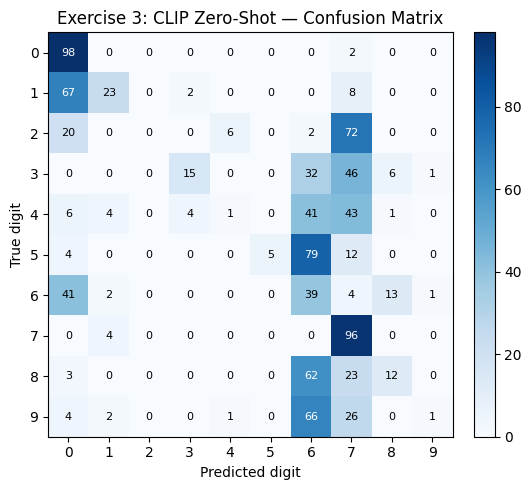


Stored results under "CLIP (Zero-Shot VLM)".


In [61]:
accuracy_vlm = accuracy_score(test_labels, vlm_predictions)
print(f"Zero-shot test accuracy: {accuracy_vlm * 100:.2f}%")

VLM_LABEL = f"{VLM_CHOICE} (Zero-Shot VLM)"

plot_confusion_matrix(test_labels, vlm_predictions, f"Exercise 3: {VLM_CHOICE} Zero-Shot \u2014 Confusion Matrix")

results[VLM_LABEL] = {
    "Training required": "No",
    "Training time (s)": 0.0,
    "Inference time (s)": round(inference_time_vlm, 3),
    "Test accuracy": round(accuracy_vlm, 4),
    "Parameters": n_params_vlm,
}

print(f'\nStored results under "{VLM_LABEL}".')

**Try it yourself (optional):** go back to Step 2 and reword the prompt — for CLIP try `f"the number {digit}"` or `f"a digit {digit}, black ink on white paper"`; for BLIP-VQA try `"What single digit from 0 to 9 is handwritten in this image? Reply with only the digit."` Then re-run Steps 3 and 4. Notice how much the accuracy shifts just from rewording. This is a real and important phenomenon with foundation models: how you *ask* affects what you get back.

**Want to compare both VLMs side by side?** Scroll back up, pick the other model from the dropdown, re-run the "lock in your choice" cell, then re-run Steps 1–4. Since each model's results are stored under its own key (`"CLIP (Zero-Shot VLM)"` vs. `"BLIP-VQA (Zero-Shot VLM)"`), running both doesn't overwrite anything — Section 4 will simply show **four** methods side by side instead of three.

---
# 4. Head-to-Head Comparison

We've now solved the same classification task three different ways, on the exact same data. Let's put the results side by side.


In [62]:
summary_df = pd.DataFrame(results).T
summary_df.index.name = "Method"
summary_df = summary_df[["Training required", "Training time (s)", "Inference time (s)", "Test accuracy", "Parameters"]]
summary_df["Parameters"] = summary_df["Parameters"].apply(lambda x: f"{int(x):,}")
summary_df["Test accuracy"] = (summary_df["Test accuracy"].astype(float) * 100).round(2).astype(str) + "%"
summary_df

,Training required,Training time (s),Inference time (s),Test accuracy,Parameters
Method,,,,,
Logistic Regression,Yes,7.73,0.007,88.7%,"7,850"
MLP (PyTorch),Yes,13.3,0.123,94.4%,"235,146"
CLIP (Zero-Shot VLM),No,0.0,68.813,29.0%,"151,277,313"


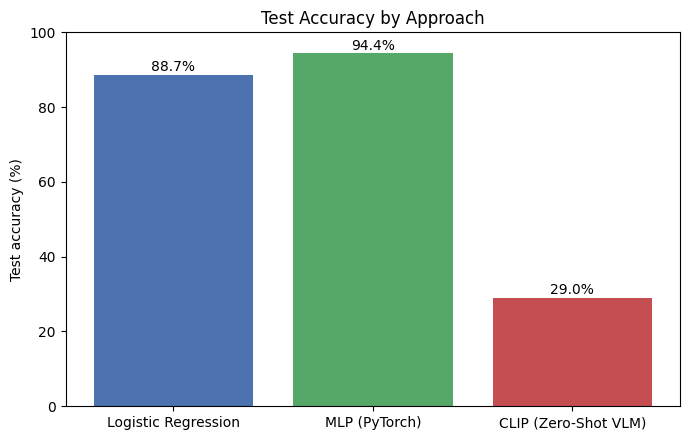

In [63]:
methods = list(results.keys())
accuracies = [results[m]["Test accuracy"] * 100 for m in methods]

# A small qualitative palette, cycled if there end up being more than 6 methods
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
colors = [palette[i % len(palette)] for i in range(len(methods))]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel("Test accuracy (%)")
plt.title("Test Accuracy by Approach")
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc:.1f}%", ha="center")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Discussion

Take a few minutes to discuss these questions with the people around you:

- Which method got the highest accuracy on this task? Does that match what you expected before we started?
- Which method required the least effort and setup? Which required the most?
- The VLM you chose was never trained on a single MNIST digit, yet it produced predictions. What does its accuracy tell you about the strengths *and* limits of zero-shot, general-purpose models?
- If you had 1 million **unlabeled** images and needed a rough sort quickly, which method would you reach for? What if you had time to carefully label 6,000 images and needed the highest possible accuracy?
- What would you expect to happen to each method's accuracy if we trained on the *full* 60,000-image MNIST training set instead of our 6,000-image subset?
- **If time allows:** run Exercise 3 again with the other VLM. Did CLIP's embedding-matching approach or BLIP-VQA's generate-an-answer approach do better on handwritten digits? Why might that be?

---
# 5. Bonus — Text-to-Speech with Kokoro

*This section is optional — a fun capstone if time allows, or something to try on your own afterward.*

So far we've worked entirely with images. AI models can work with other modalities too — including audio. **Kokoro** is a small (82 million parameter), open-weight, Apache-2.0 licensed text-to-speech model available on Hugging Face. Despite its small size, it produces natural-sounding speech and runs comfortably on a Colab GPU (or even CPU).

Let's use it to read our own results out loud.


In [65]:
# Install Kokoro and its dependencies.
# espeak-ng is a phonemizer engine Kokoro uses under the hood to convert text to sounds.
!pip install -q "kokoro>=0.9.2" soundfile
!apt-get -qq -y install espeak-ng > /dev/null 2>&1
print("Kokoro installed.")

Kokoro installed.


In [64]:
import numpy as np
from scipy.io import wavfile
from kokoro import KPipeline
from IPython.display import display, Audio

tts_pipeline = KPipeline(lang_code="a")  # 'a' = American English

vlm_lines = "".join(
    f"The zero shot {choice.replace('-', ' ')} model reached "
    f"{results[f'{choice} (Zero-Shot VLM)']['Test accuracy'] * 100:.1f} percent accuracy. "
    for choice in ("CLIP", "BLIP-VQA")
    if f"{choice} (Zero-Shot VLM)" in results
)

results_text = (
    f"Here are today's results. "
    f"The logistic regression baseline reached {results['Logistic Regression']['Test accuracy'] * 100:.1f} percent accuracy. "
    f"The multi layer perceptron reached {results['MLP (PyTorch)']['Test accuracy'] * 100:.1f} percent accuracy after training. "
    f"{vlm_lines}"
    f"All without a single training example for the vision language model."
)

print("Generating speech for:\n")
print(results_text)

audio_generator = tts_pipeline(results_text, voice="af_heart")
all_audio_chunks = []  # List to hold the audio segments

for i, (graphemes, phonemes, audio) in enumerate(audio_generator):
    # Display and play in the notebook
    display(Audio(data=audio, rate=24000, autoplay=(i == 0)))

    # Store the chunk for saving
    all_audio_chunks.append(audio)

# Combine all generated chunks into one continuous array
final_audio = np.concatenate(all_audio_chunks)

# Save the complete audio to a WAV file
wavfile.write("results_summary.wav", 24000, final_audio)
print("Saved to results_summary.wav!")

In [66]:
# # if HF downoload taking time

# import os
# import tarfile

# # ------------------------------------------------------------------
# # Download Kokoro model from Google Drive
# # ------------------------------------------------------------------

# KOKORO_FILE_ID = "1twYtP7lv2s0gH6J4ZNbOU6u7DRQnYIMn"
# TAR_PATH = "kokoro_model.tar.gz"
# EXTRACT_DIR = "./"
# MODEL_DIR = "./kokoro_model"

# if not os.path.exists(MODEL_DIR):
#     print("Downloading Kokoro model from Google Drive...")
#     os.system(f"gdown --id {KOKORO_FILE_ID} -O {TAR_PATH}")

#     print("Extracting Kokoro model...")
#     with tarfile.open(TAR_PATH, "r:gz") as tar:
#         tar.extractall(EXTRACT_DIR)

# print("Kokoro model ready.")

Extracting Kokoro model...


/tmp/ipykernel_188/238470065.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


Kokoro model ready.


In [74]:
# import numpy as np
# from scipy.io import wavfile
# from kokoro import KPipeline
# from kokoro.model import KModel
# from IPython.display import display, Audio

# MODEL_DIR = "./kokoro_model"

# config_path = os.path.join(MODEL_DIR, "config.json")
# model_path = os.path.join(MODEL_DIR, "kokoro-v1_0.pth")

# print("Config:", config_path)
# print("Model:", model_path)

# print("Loading local Kokoro weights...")

# model = KModel(
#     config=config_path,
#     model=model_path
# ).to("cuda" if torch.cuda.is_available() else "cpu")

# model.eval()

# tts_pipeline = KPipeline(
#     lang_code="a",
#     model=model
# )

# vlm_lines = "".join(
#     f"The zero shot {choice.replace('-', ' ')} model reached "
#     f"{results[f'{choice} (Zero-Shot VLM)']['Test accuracy'] * 100:.1f} percent accuracy. "
#     for choice in ("CLIP", "BLIP-VQA")
#     if f"{choice} (Zero-Shot VLM)" in results
# )

# results_text = (
#     f"Here are today's results. "
#     f"The logistic regression baseline reached {results['Logistic Regression']['Test accuracy'] * 100:.1f} percent accuracy. "
#     f"The multi layer perceptron reached {results['MLP (PyTorch)']['Test accuracy'] * 100:.1f} percent accuracy after training. "
#     f"{vlm_lines}"
#     f"All without a single training example for the vision language model."
# )

# print("Generating speech for:\n")
# print(results_text)

# audio_generator = tts_pipeline(results_text, voice="af_heart")
# all_audio_chunks = []  # List to hold the audio segments

# for i, (graphemes, phonemes, audio) in enumerate(audio_generator):
#     # Display and play in the notebook
#     display(Audio(data=audio, rate=24000, autoplay=(i == 0)))

#     # Store the chunk for saving
#     all_audio_chunks.append(audio)

# # Combine all generated chunks into one continuous array
# final_audio = np.concatenate(all_audio_chunks)

# # Save the complete audio to a WAV file
# wavfile.write("results_summary.wav", 24000, final_audio)
# print("Saved to results_summary.wav!")

Config: ./kokoro_model/config.json
Model: ./kokoro_model/kokoro-v1_0.pth
Loading local Kokoro weights...
Generating speech for:

Here are today's results. The logistic regression baseline reached 88.7 percent accuracy. The multi layer perceptron reached 94.4 percent accuracy after training. The zero shot CLIP model reached 29.0 percent accuracy. All without a single training example for the vision language model.


voices/af_heart.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

Saved to results_summary.wav!


Feel free to change `results_text` to anything you like, or try a different `voice` (Kokoro ships with several — check the [model card](https://huggingface.co/hexgrad/Kokoro-82M) for the full list).

---
# Wrap-Up

Today we solved one task three different ways:

- **Logistic Regression** — fast, simple, interpretable, but limited by treating pixels independently
- **MLP (PyTorch)** — learns richer patterns through training, at the cost of more compute and more parameters
- **A zero-shot VLM (CLIP or BLIP-VQA)** — no training required at all, leveraging knowledge learned from massive-scale pretraining, with accuracy that depends heavily on how well the task matches what the model was trained on


### Where to go from here
- [PyTorch official tutorials](https://pytorch.org/tutorials/) — build on the MLP you trained today
- [Hugging Face course](https://huggingface.co/course) — a free, thorough introduction to using pretrained models
- [The CLIP paper](https://arxiv.org/abs/2103.00020) — for anyone curious how CLIP's zero-shot classification works under the hood
- [The BLIP-VQA model card](https://huggingface.co/Salesforce/blip-vqa-base) — for anyone curious how this VLM was built and what else it can do
- [Kokoro model card](https://huggingface.co/hexgrad/Kokoro-82M) — more voices and languages to try

<!-- ```
Rochana Obadage
07/09/2026
``` -->
<br>

---

Instructor: [Rochana R. Obadage](https://rochanaro.github.io/)<br>
Last Updated: _14th July 2026_